# Assignment 8

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


How many rows does this dataset have?

In [3]:
len(df)

716165

How many North Atlantic hurricanes are in this dataset?

In [31]:
df.groupby('BASIN')['SID'].nunique().loc['NA']

2344

## 1) Get the unique values of the BASIN, SUBBASIN, and NATURE columns

In [9]:
print("BASIN:", df['BASIN'].unique())
print("SUBBASIN:", df['SUBBASIN'].unique())
print("NATURE:", df['NATURE'].unique())

BASIN: ['NI' 'SI' 'NA' 'EP' 'WP' 'SP' 'SA']
SUBBASIN: ['BB' 'AS' 'MM' 'GM' 'NA' 'CS' 'WA' 'EA' 'CP']
NATURE: ['NR' 'TS' 'ET' 'SS' 'MX' 'DS']


## 2) Rename the WMO_WIND and WMO_PRES columns to WIND and PRES

In [10]:
df = df.rename(columns={'WMO_WIND': 'WIND', 'WMO_PRES': 'PRES'})

In [11]:
print(df.columns)

Index(['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME',
       'NATURE', 'LAT', 'LON', 'WIND', 'PRES'],
      dtype='object')


## 3) Get the 10 largest rows in the dataset by WIND

In [12]:
df.nlargest(10, 'WIND')

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


## 4) Group the data on SID and get the 10 largest hurricanes by WIND

In [13]:
storms = df.groupby('SID').agg({
    'WIND': 'max',
    'NAME': 'first'
})

storms.nlargest(10, 'WIND')

,WIND,NAME
SID,,
2015293N13266,185.0,PATRICIA
1980214N11330,165.0,ALLEN
1935241N23291,160.0,None
1988253N12306,160.0,GILBERT
1997253N12255,160.0,LINDA
2005289N18282,160.0,WILMA
2019236N10314,160.0,DORIAN
1998295N12284,155.0,MITCH
2005261N21290,155.0,RITA


In [23]:
#if you don't want us including the unnamed hurricane then we can use this instead

top_10_named = df.groupby(['SID', 'NAME'])['WIND'].max().nlargest(10)
print(top_10_named)

SID            NAME    
2015293N13266  PATRICIA    185.0
1980214N11330  ALLEN       165.0
1988253N12306  GILBERT     160.0
1997253N12255  LINDA       160.0
2005289N18282  WILMA       160.0
2019236N10314  DORIAN      160.0
1998295N12284  MITCH       155.0
2005261N21290  RITA        155.0
2009288N07267  RICK        155.0
2017242N16333  IRMA        155.0
Name: WIND, dtype: float64


## 5) Make a bar chart of the wind speed of the 20 strongest-wind hurricanes

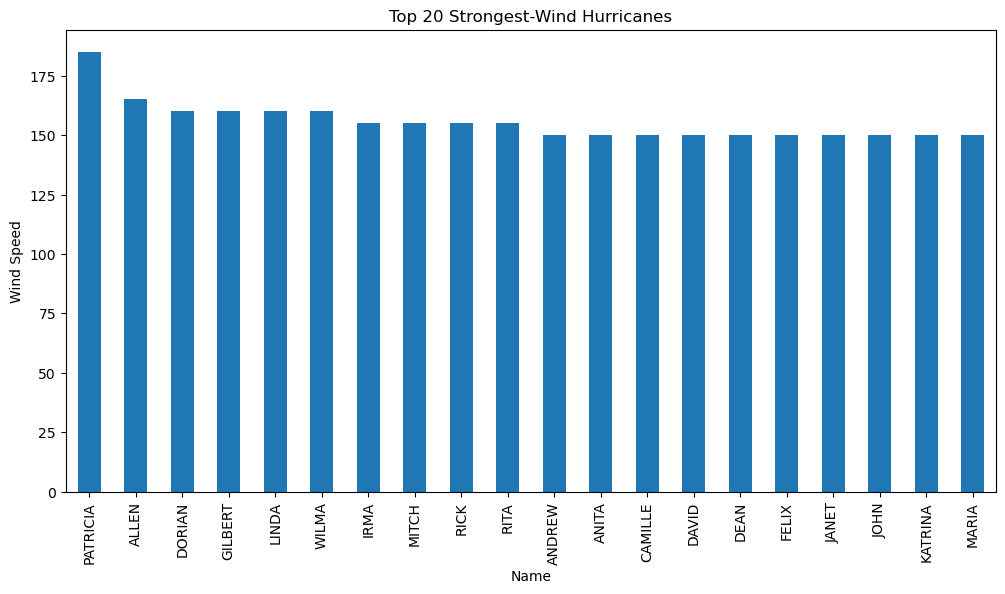

In [26]:
top_20_storms = df.groupby(['NAME'])['WIND'].max().nlargest(20)

top_20_storms.plot(kind='bar', figsize=(12, 6))
plt.title('Top 20 Strongest-Wind Hurricanes')
plt.ylabel('Wind Speed')
plt.xlabel('Name')
plt.show()

## 6) Plot the count of all datapoints by Basin

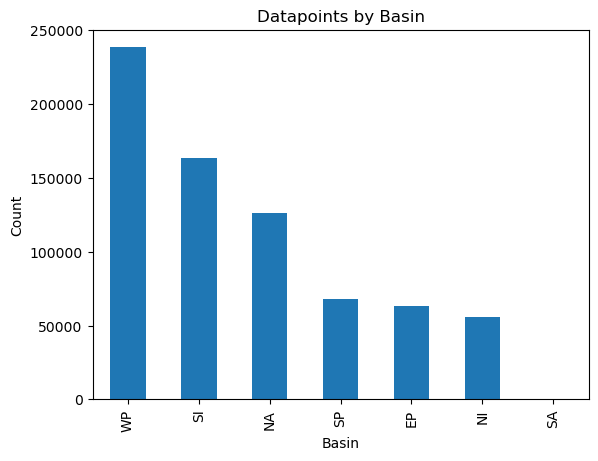

In [36]:
basin_counts = df.groupby('BASIN').size().sort_values(ascending=False)

basin_counts.plot(kind='bar')
plt.title('Datapoints by Basin')
plt.xlabel('Basin')
plt.ylabel('Count')
plt.show()

## 7) Plot the count of unique hurricanes by Basin

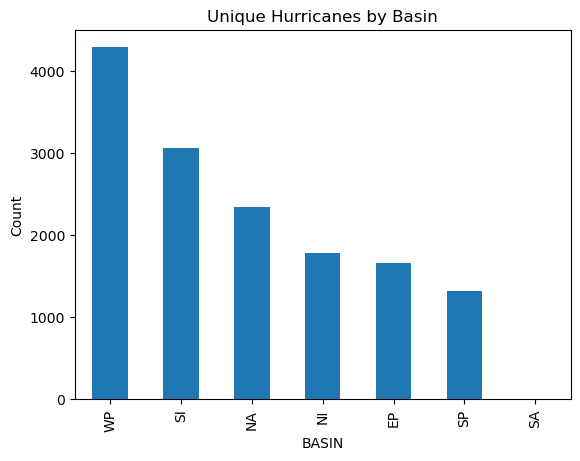

In [44]:
df.groupby('BASIN')['SID'].nunique().sort_values(ascending=False).plot(kind='bar', title="Unique Hurricanes by Basin")
plt.ylabel('Count')
plt.show()

## 8) Make a hexbin of the location of datapoints in Latitude and Longitude

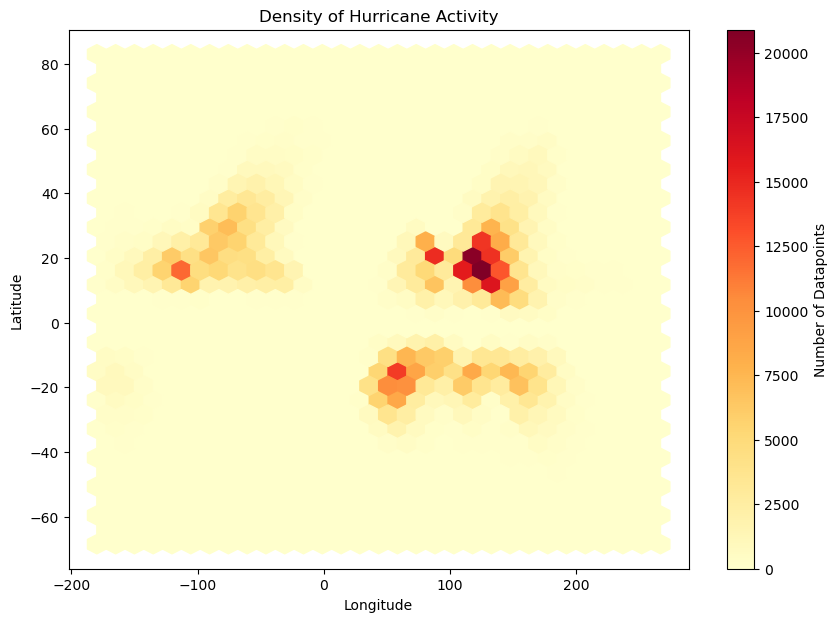

In [56]:
ax = df.plot.hexbin(x='LON', y='LAT', gridsize=30, cmap='YlOrRd', figsize=(10, 7), title="Density of Hurricane Activity", colorbar=False)

plt.colorbar(ax.collections[0], label='Number of Datapoints')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

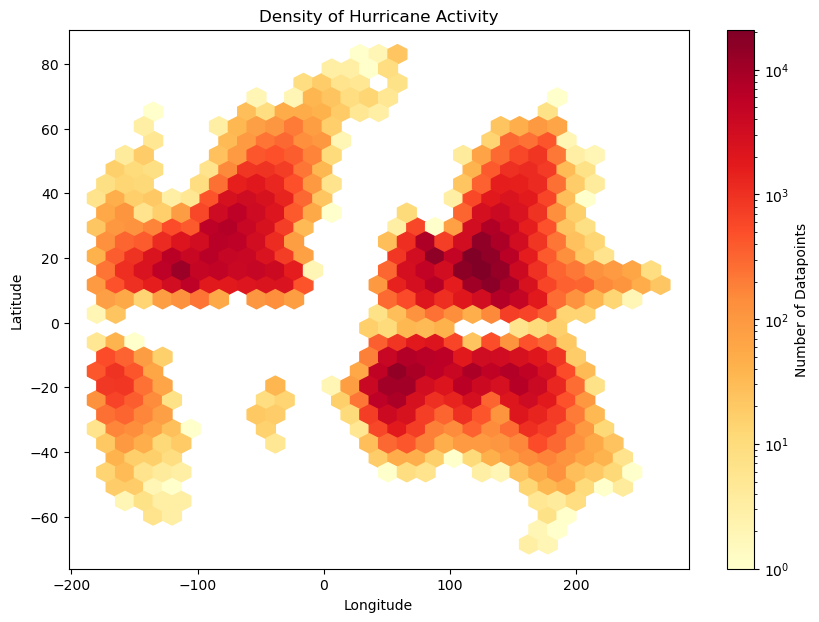

In [59]:
#Another option with log scale which we can check out too
ax = df.plot.hexbin(x='LON', y='LAT', gridsize=30, cmap='YlOrRd', figsize=(10, 7), title="Density of Hurricane Activity", colorbar=False, bins='log')

plt.colorbar(ax.collections[0], label='Number of Datapoints')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

## 9) Find Hurricane Katrina (from 2005) and plot its track as a scatter plot

In [61]:
katrina_sid = df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)]['SID'].unique()[0]
katrina_sid

'2005236N23285'

In [66]:
katrina_track = df.groupby('SID').get_group(katrina_sid)

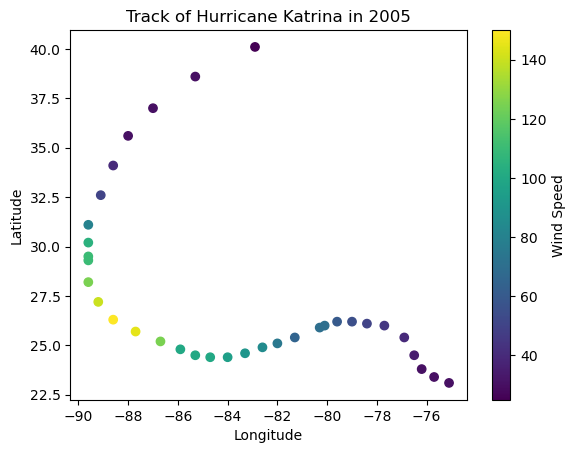

In [75]:
plt.scatter(
    katrina_track['LON'],
    katrina_track['LAT'],
    c=katrina_track['WIND']
)

plt.colorbar(label='Wind Speed')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Track of Hurricane Katrina in 2005')
plt.show()

## 10) Make time the index on your dataframe

In [87]:
df = df.set_index('ISO_TIME')

In [90]:
df = df.sort_index()

In [91]:
df.index

DatetimeIndex(['1842-10-25 03:00:00', '1842-10-25 06:00:00',
               '1842-10-25 09:00:00', '1842-10-25 12:00:00',
               '1842-10-25 15:00:00', '1842-10-25 18:00:00',
               '1842-10-25 21:00:00', '1842-10-26 00:00:00',
               '1842-10-26 03:00:00', '1842-10-26 06:00:00',
               ...
               '2024-05-27 09:00:00', '2024-05-27 09:00:00',
               '2024-05-27 12:00:00', '2024-05-27 12:00:00',
               '2024-05-27 15:00:00', '2024-05-27 15:00:00',
               '2024-05-27 18:00:00', '2024-05-27 18:00:00',
               '2024-05-27 21:00:00', '2024-05-28 00:00:00'],
              dtype='datetime64[ns]', name='ISO_TIME', length=716165, freq=None)

## 11) Plot the count of all datapoints per year as a timeseries

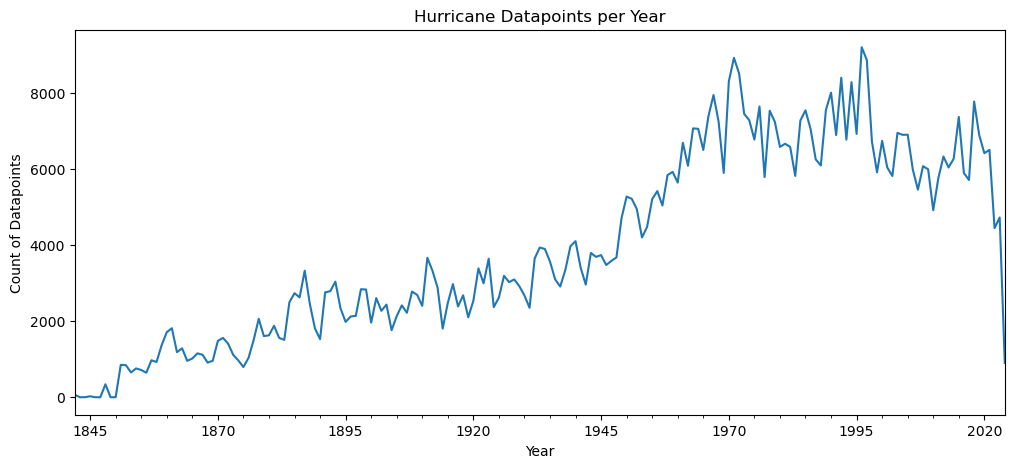

In [96]:
yearly_activity = df.resample('YE').size()
yearly_activity.plot(figsize=(12, 5), title="Hurricane Datapoints per Year")
plt.ylabel("Count of Datapoints")
plt.xlabel('Year')
plt.show()

Which years stand out as having anomalous hurricane activity?

Around 1971 stands out as a peak for a high number of hurricane datapoints per year, as well as around 1996. The end of the timeseries also stands out as having a strong decline in hurricane datapoints. However, I think that we should be careful in our interpretation, as hurricane datapoints is not exactly the same as hurricanes, and I would guess that our detection ability and capacity is influencing the number of hurricane datapoints as well.